In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="whitegrid")

In [4]:
#Convertir dataset a dataframe de pandas
df = pd.read_csv("./clientes.csv", delimiter=";")
print(df.head())

   age            job   marital  education default  balance housing loan  \
0   35         admin.   married  secondary      no     2070     yes  yes   
1   69   entrepreneur   married  secondary      no      526      no  yes   
2   23     technician  divorced   tertiary      no     5910     yes   no   
3   41    blue-collar   married   tertiary      no     4437     yes   no   
4   32  self-employed   married   tertiary      no     2725     yes   no   

     contact  day month  duration  campaign  pdays  previous poutcome    y  
0   cellular    7   apr       401         1     -1         0  unknown   no  
1  telephone   13   feb       326         1     -1         0  unknown   no  
2    unknown    2   nov       268         1     -1         0  unknown  yes  
3  telephone    6   sep       493         2    386         5  failure   no  
4  telephone   13   nov       380         1     -1         0  unknown   no  


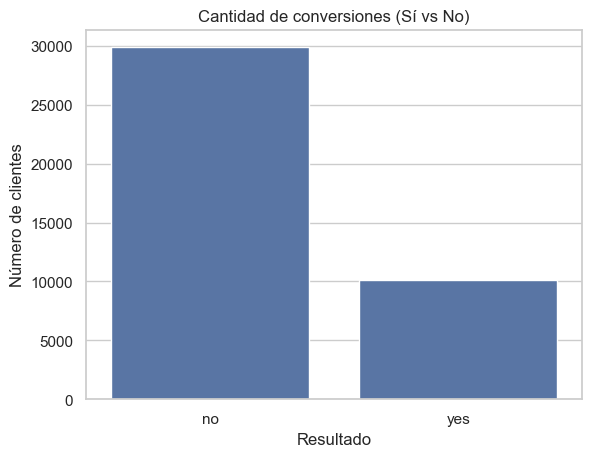

In [6]:
# 1. GRÁFICA DE BARRAS - CONVERSIONES (YES/NO)
resultado_counts = df['y'].value_counts()

plt.figure()
sns.barplot(x=resultado_counts.index, y=resultado_counts.values)
plt.title("Cantidad de conversiones (Sí vs No)")
plt.xlabel("Resultado")
plt.ylabel("Número de clientes")
plt.show()

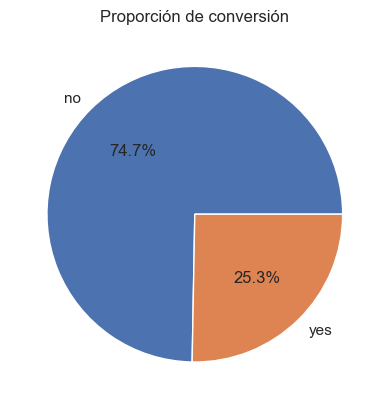

In [7]:
# 2. GRÁFICA DE PASTEL - CONVERSIÓN
plt.figure()
plt.pie(resultado_counts.values, labels=resultado_counts.index, autopct='%1.1f%%')
plt.title("Proporción de conversión")
plt.show()

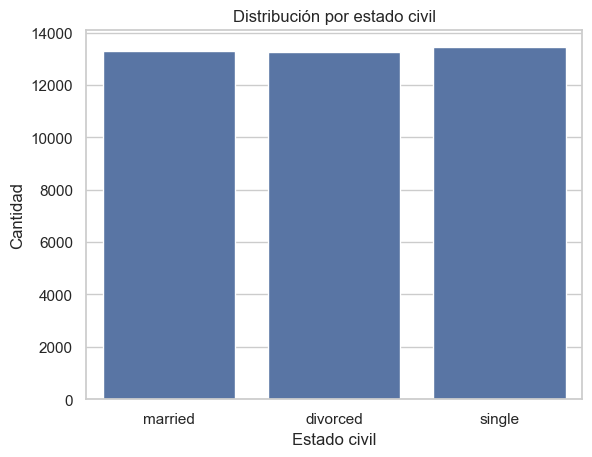

In [8]:
# 3. GRÁFICA DE BARRAS - ESTADO CIVIL
plt.figure()
sns.countplot(data=df, x='marital')
plt.title("Distribución por estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Cantidad")
plt.show()

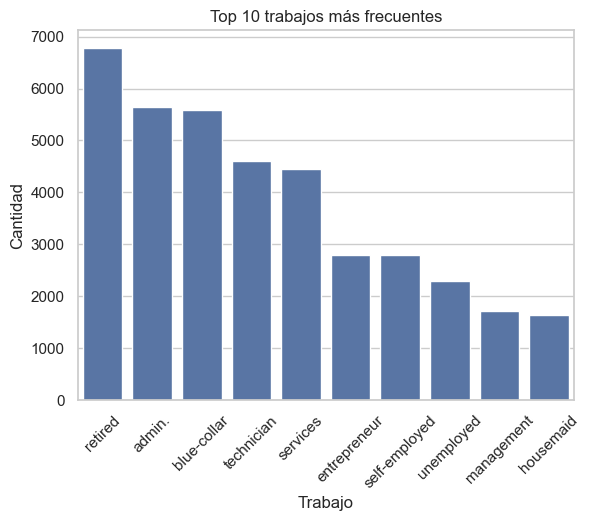

In [9]:
# 4. GRÁFICA DE BARRAS - TRABAJO (TOP 10)
top_jobs = df['job'].value_counts().nlargest(10)

plt.figure()
sns.barplot(x=top_jobs.index, y=top_jobs.values)
plt.title("Top 10 trabajos más frecuentes")
plt.xlabel("Trabajo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

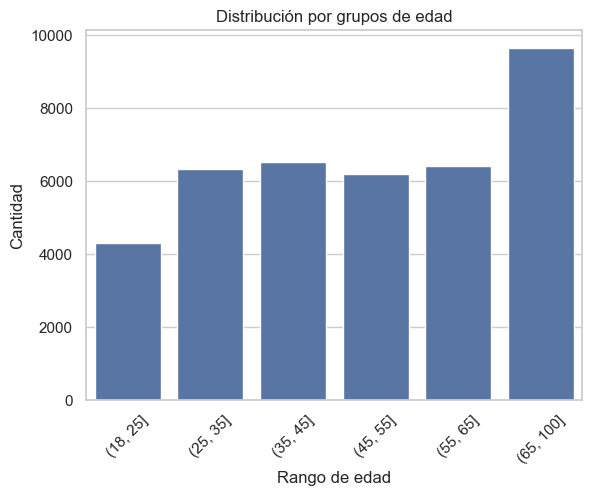

In [10]:
# 5. GRÁFICA DE BARRAS - GRUPOS DE EDAD
df['age_group'] = pd.cut(df['age'], bins=[18,25,35,45,55,65,100])

plt.figure()
sns.countplot(data=df, x='age_group')
plt.title("Distribución por grupos de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

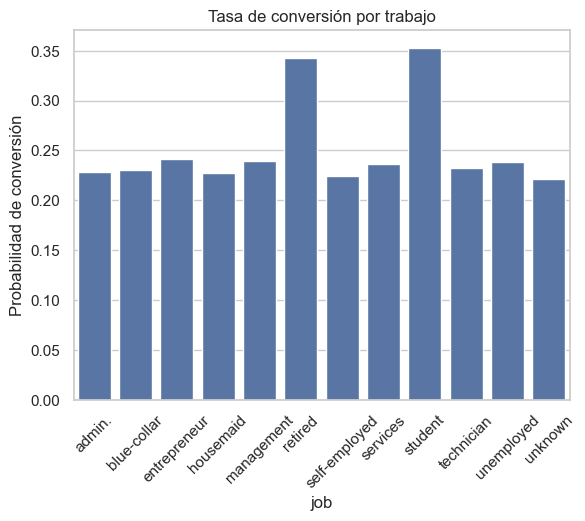

In [11]:
# 6. # TASA DE CONVERSIÓN POR TRABAJO
conversion_job = df.groupby("job")["y"].apply(lambda x: (x == "yes").mean()).reset_index()
conversion_job.columns = ["job", "tasa_conversion"]

plt.figure()
sns.barplot(data=conversion_job, x="job", y="tasa_conversion")
plt.title("Tasa de conversión por trabajo")
plt.xticks(rotation=45)
plt.ylabel("Probabilidad de conversión")
plt.show()

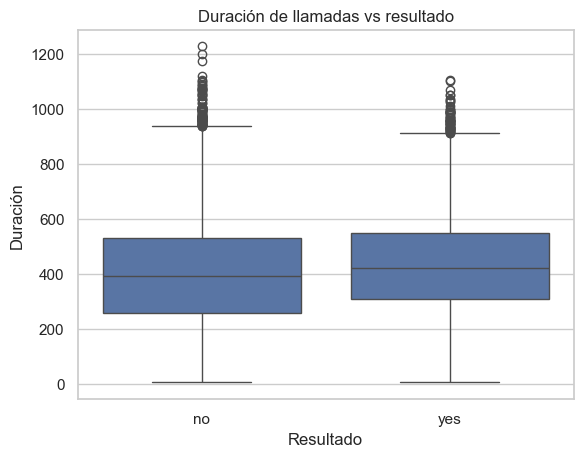

In [12]:
# 7. DURACIÓN VS CONVERSIÓN
plt.figure()
sns.boxplot(data=df, x="y", y="duration")
plt.title("Duración de llamadas vs resultado")
plt.xlabel("Resultado")
plt.ylabel("Duración")
plt.show()